# Chapter 4. Which Q2 orders were never paid, and which payments did the gateway post twice?

**Week 2, Tuesday · Chapter 4 of 6 · Booked against collected.**

> **The client asks.** "Booked revenue is not collected revenue. Some orders are paid in two
> instalments, some are refunded, some were never paid at all. Show me, order by order, what we
> actually collected against what we booked in Q2. If there is a gap, I want to know which orders
> and which channel."
>
> Anand Iyer, finance controller, Kalpa Retail

The data platform lead added the payments table to the team's access and said, in passing, that
the payments feed "sometimes double-posts when the gateway retries".

**Who needs the answer.** Anand's collections team rings the customers on the unpaid list, and the data platform lead and Finance reverse or refund what is on the double-paid list. A wrong unpaid list chases a customer who paid or misses one who did not; a wrong double-paid list reverses a legitimate second instalment and rings a business buyer who paid on time.

**The questions on the way.**
1. Which orders have no payment at all?
2. What happens to the unpaid list when "paid in Q2" goes into the WHERE clause?
3. Where does a condition on the payments table belong?
4. Which orders does HAVING COUNT(*) > 1 flag, and are they double-paid?
5. What makes a retry a retry, and does each list match its bar?
6. Do a second method and a second list reach the same orders?

**The metric at stake.** Two moves of the bridge carry names: the booked value of orders never paid, and the cash posted twice. Each list is right only when its total equals its bar.

**What came before, and what this adds.** Chapter 3 proved the report keeps every Q2 order, 462 rows for 462 orders, and built the bridge from booked to posted. On the invented tables it reads booked 5,800, less 800 never paid, is collected 5,000, plus 1,500 posted twice, is posted 6,500; on Kalpa's Q2 you ran it and it closed at every step. Each bar is a total, and Anand asked for names. This chapter writes the list behind each bar.

**Setup.** The next cell finds the helper, connects to the warehouse and creates the invented tables
of chapter 1. Every query below is also in `sql/C2_W02_D02_04_which_orders_STUDENT.sql`.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit
from decimal import Decimal

TINY = """DROP TABLE IF EXISTS pg_temp.tiny_orders, pg_temp.tiny_payments;
CREATE TEMP TABLE tiny_orders (
    order_id  text PRIMARY KEY,
    channel   text NOT NULL,
    amount    numeric(12, 2) NOT NULL
);
CREATE TEMP TABLE tiny_payments (
    payment_id    text PRIMARY KEY,
    order_id      text NOT NULL,
    paid_date     date NOT NULL,
    amount        numeric(12, 2) NOT NULL,
    instalment_no integer NOT NULL
);
INSERT INTO tiny_orders VALUES
    ('T-1', 'app',   1000),
    ('T-2', 'web',   2000),
    ('T-3', 'store', 1500),
    ('T-4', 'app',    800),
    ('T-5', 'store',  500);
INSERT INTO tiny_payments VALUES
    ('P-1', 'T-1', '2026-07-03', 1000, 1),
    ('P-2', 'T-2', '2026-07-05', 1200, 1),
    ('P-3', 'T-2', '2026-08-05',  800, 2),
    ('P-4', 'T-3', '2026-07-09', 1500, 1),
    ('P-5', 'T-3', '2026-07-09', 1500, 1),
    ('P-6', 'T-5', '2026-07-12',  500, 1),
    ('P-7', 'T-9', '2026-07-14',  600, 1);"""

conn = kit.connect()
conn.autocommit = True
with conn.cursor() as cur:
    cur.execute(TINY)            # invented, TEMP, so they vanish when this notebook stops


def run(query, params=None):
    """Run a query on this notebook's one connection and return its rows as dictionaries."""
    return kit.sql(query, params, conn=conn)


def one(query, params=None):
    """The first value of the first row, for a query that returns a single number."""
    row = run(query, params)[0]
    return next(iter(row.values()))


def show(rows, caption="", money=()):
    """Rows as the kit's table; columns named in money print as rupees."""
    if not rows:
        return kit.table(["result"], [["no rows"]], caption)
    heads = list(rows[0])
    body = []
    for r in rows:
        line = []
        for h in heads:
            v = r[h]
            if v is None:
                line.append("NULL")
            elif h in money:
                line.append(kit.rupees(v))
            elif isinstance(v, Decimal):
                line.append(f"{int(v):,}" if v == v.to_integral_value() else f"{float(v):,.2f}")
            else:
                line.append(str(v))
        body.append(line)
    kit.table(heads, body, caption)

Q_BRIDGE = """WITH per_order AS (
WITH per_instalment AS (
    SELECT order_id, instalment_no, max(amount) AS amount
    FROM payments
    GROUP BY order_id, instalment_no
),
collected_per_order AS (
    SELECT order_id, sum(amount) AS collected
    FROM per_instalment
    GROUP BY order_id
),
posted_per_order AS (
    SELECT order_id, sum(amount) AS posted
    FROM payments
    GROUP BY order_id
)
SELECT o.order_id, o.channel, o.amount AS booked, c.collected, p.posted
FROM orders o
LEFT JOIN collected_per_order c ON c.order_id = o.order_id
LEFT JOIN posted_per_order p    ON p.order_id = o.order_id
WHERE o.quarter = 'Q2'
)
SELECT sum(booked)                                                    AS booked,
       sum(booked) FILTER (WHERE collected IS NULL)                   AS never_paid,
       coalesce(sum(booked - collected) FILTER (WHERE collected < booked), 0) AS paid_short,
       sum(collected)                                                 AS collected,
       sum(posted - collected)                                        AS posted_twice,
       sum(posted)                                                    AS posted
FROM per_order"""
kb = {k: (v or 0) for k, v in run(Q_BRIDGE)[0].items()}
tb = {k: (v or 0) for k, v in run("""WITH per_order AS (
WITH per_instalment AS (
    SELECT order_id, instalment_no, max(amount) AS amount
    FROM tiny_payments
    GROUP BY order_id, instalment_no
),
collected_per_order AS (
    SELECT order_id, sum(amount) AS collected
    FROM per_instalment
    GROUP BY order_id
),
posted_per_order AS (
    SELECT order_id, sum(amount) AS posted
    FROM tiny_payments
    GROUP BY order_id
)
SELECT o.order_id, o.channel, o.amount AS booked, c.collected, p.posted
FROM tiny_orders o
LEFT JOIN collected_per_order c ON c.order_id = o.order_id
LEFT JOIN posted_per_order p    ON p.order_id = o.order_id
)
SELECT sum(booked)                                                    AS booked,
       sum(booked) FILTER (WHERE collected IS NULL)                   AS never_paid,
       coalesce(sum(booked - collected) FILTER (WHERE collected < booked), 0) AS paid_short,
       sum(collected)                                                 AS collected,
       sum(posted - collected)                                        AS posted_twice,
       sum(posted)                                                    AS posted
FROM per_order""")[0].items()}
print("Chapter 3's bridge is rebuilt for Kalpa's Q2 and for the invented tables; its figures stay unprinted.")

Chapter 3's bridge is rebuilt for Kalpa's Q2 and for the invented tables; its figures stay unprinted.


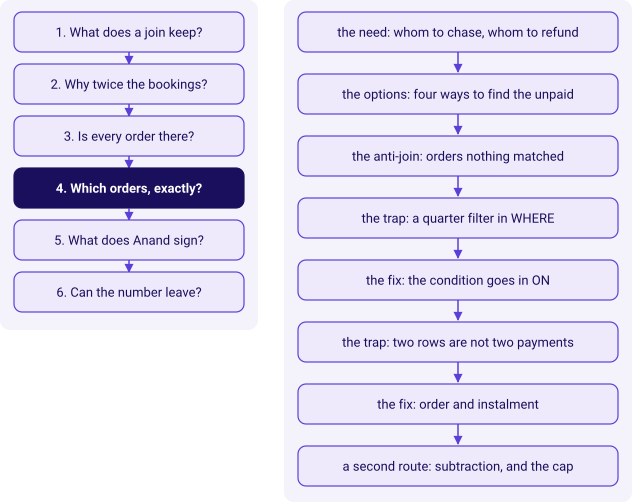

In [2]:
kit.side_by_side(
    kit.ladder(['What does a join keep?', 'Why twice the bookings?', 'Is every order there?', 'Which orders, exactly?', 'What does Anand sign?', 'Can the number leave?'], lit=3, show=False),
    kit.vflow(['the need: whom to chase, whom to refund', 'the options: four ways to find the unpaid', 'the anti-join: orders nothing matched', 'the trap: a quarter filter in WHERE', 'the fix: the condition goes in ON', 'the trap: two rows are not two payments', 'the fix: order and instalment', 'a second route: subtraction, and the cap'], show=False),
)

## Whom does Anand chase, and whom does he refund?

Each list goes to a different desk and triggers an action with a cost. The unpaid list goes to the
collections team, who ring every customer on it, and every order on it is cash Kalpa is owed. The double-paid list goes to the platform lead, who fixes the
feed, and to Finance, who checks with the bank whether the customer was charged twice and, if so,
refunds them. A name on the wrong list is a phone call to a customer who did nothing wrong, and a
name missing is money left where it is. The retail story behind Anand's role, how a sale becomes cash and who checks it, is in the domain dossier, `content/W01/D1/study-notes/C2_W01_D01_domain_retail_STUDENT.md`, sections 3 and 4.

**Who else faces this.** Stripe builds its payments API so that a retried request cannot charge
twice: the client sends an idempotency key, Stripe saves the result of the first request made with
it, and "subsequent requests with the same key return the same result" (Stripe API reference,
Idempotent requests, checked 1 Oct 2026). India's regulator sets a deadline for the other side of
the same problem. Under the Reserve Bank of India's circular of 20 September 2019, when a customer's
account is debited for an online card payment and the merchant's system never receives the
confirmation, the debit must be reversed automatically within five days of the transaction, with compensation of
Rs 100 for every day of delay after that (RBI/2019-20/67, in force from 15 October 2019, checked 1
Oct 2026). A payment posted twice can be money a customer is owed back.

**The two invented tables.** They hold five orders and seven payments, invented to carry every
case Anand named and the one the platform lead mentioned, so every row can be checked by hand:

| order_id | channel | amount | What happened to it |
|---|---|---|---|
| T-1 | app | 1,000 | Paid once, in full (P-1) |
| T-2 | web | 2,000 | Paid in two instalments, 1,200 and 800 (P-2, P-3) |
| T-3 | store | 1,500 | Paid once, and the gateway posted that payment twice (P-4, P-5) |
| T-4 | app | 800 | Never paid |
| T-5 | store | 500 | Paid once, in full (P-6) |

P-7 is a payment of 600 against T-9, an order that is not in the orders table.

## Which of four ways finds the unpaid orders, and what does each cost here?

An order that nothing matched is found with an anti-join: keep the rows of one table that have no
partner in the other. SQL offers four ways to write one.

| Option | Written as | What it assumes |
|---|---|---|
| A. LEFT JOIN, then keep the misses | `LEFT JOIN payments p ... WHERE p.order_id IS NULL` | The right table's key is never NULL on a real match |
| B. NOT EXISTS | `WHERE NOT EXISTS (SELECT 1 FROM payments p WHERE p.order_id = o.order_id)` | Nothing |
| C. NOT IN | `WHERE o.order_id NOT IN (SELECT order_id FROM payments)` | The subquery never returns a NULL |
| D. EXCEPT | `SELECT order_id FROM orders EXCEPT SELECT order_id FROM payments` | Only the ids are wanted |

The cell below runs all four on Kalpa's Q2 and times them, checks that they agree without printing
the list, and then shows on the invented tables what happens to C when a single payment arrives
with no order reference, which a feed can send.

Option,Carries the order's columns,"With one NULL payment, invented",Time on Kalpa's Q2
A. LEFT JOIN ... IS NULL,yes,still finds T-4,1.6 ms
B. NOT EXISTS,yes,still finds T-4,0.9 ms
C. NOT IN,yes,"finds 0 orders, where it found 1",0.8 ms
D. EXCEPT,ids only,still finds T-4,0.8 ms


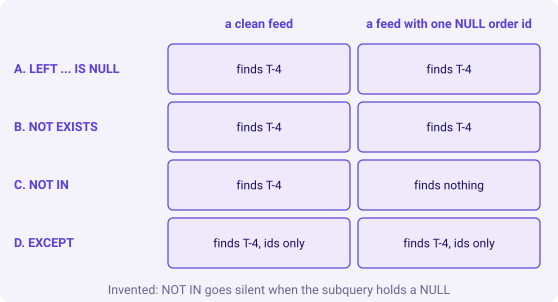

In [3]:
import time
timed = {}
for name, q in [("A. LEFT JOIN ... IS NULL", """
SELECT o.order_id, o.channel, o.order_date, o.amount AS booked
FROM orders o
LEFT JOIN payments p ON p.order_id = o.order_id
WHERE o.quarter = 'Q2'
  AND p.order_id IS NULL
ORDER BY o.amount DESC"""),
                ("B. NOT EXISTS", """
SELECT o.order_id
FROM orders o
WHERE o.quarter = 'Q2'
  AND NOT EXISTS (SELECT 1 FROM payments p WHERE p.order_id = o.order_id)"""),
                ("C. NOT IN", """
SELECT o.order_id
FROM orders o
WHERE o.quarter = 'Q2'
  AND o.order_id NOT IN (SELECT order_id FROM payments)"""),
                ("D. EXCEPT", """
SELECT order_id FROM orders WHERE quarter = 'Q2'
EXCEPT
SELECT order_id FROM payments""")]:
    t0 = time.perf_counter()
    ids = {r["order_id"] for r in run(q)}
    timed[name] = (ids, time.perf_counter() - t0)
not_in_clean = run("""
SELECT o.order_id
FROM tiny_orders o
WHERE o.order_id NOT IN (SELECT order_id FROM tiny_payments)""")
not_in_null = run("""
SELECT o.order_id
FROM tiny_orders o
WHERE o.order_id NOT IN (SELECT order_id FROM tiny_payments
                         UNION ALL
                         SELECT NULL)""")
kit.table(["Option", "Carries the order's columns", "With one NULL payment, invented", "Time on Kalpa's Q2"],
          [("A. LEFT JOIN ... IS NULL", "yes", "still finds T-4", f'{timed["A. LEFT JOIN ... IS NULL"][1] * 1000:.1f} ms'),
           ("B. NOT EXISTS", "yes", "still finds T-4", f'{timed["B. NOT EXISTS"][1] * 1000:.1f} ms'),
           ("C. NOT IN", "yes", f"finds {len(not_in_null)} orders, where it found {len(not_in_clean)}",
            f'{timed["C. NOT IN"][1] * 1000:.1f} ms'),
           ("D. EXCEPT", "ids only", "still finds T-4", f'{timed["D. EXCEPT"][1] * 1000:.1f} ms')],
          caption="Four anti-joins, sized")
kit.matrix(["A. LEFT ... IS NULL", "B. NOT EXISTS", "C. NOT IN", "D. EXCEPT"],
           ["a clean feed", "a feed with one NULL order id"],
           [["finds T-4", "finds T-4"], ["finds T-4", "finds T-4"], ["finds T-4", "finds nothing"],
            ["finds T-4, ids only", "finds T-4, ids only"]],
           title="Invented: NOT IN goes silent when the subquery holds a NULL")
lists = [v[0] for v in timed.values()]
kit.check("all four anti-joins return the same Q2 list on Kalpa", all(l == lists[0] for l in lists),
          "same ids, unprinted")
kit.check("NOT IN returns nothing once the subquery holds a NULL", len(not_in_null) == 0 and len(not_in_clean) == 1,
          f"{len(not_in_clean)} then {len(not_in_null)}")

**The best-fit call.** Option A, the LEFT JOIN that keeps only the misses, fits best, because it is
the same LEFT JOIN the report already runs: the unpaid list is the report's rows with nothing on the
payments side, and it carries every column Anand wants beside each order, the channel, the date and
the amount. All four take a few milliseconds and agree on today's warehouse, so they differ in what
each assumes. Avoid C: `NOT IN` compares against every value in the subquery, a
comparison with NULL is unknown, and one NULL order id in the feed makes it return no rows at all,
without an error.

**The fact that would change the call.** If the list were read as SQL by Anand's analyst, B would
read closest to his sentence, "the orders for which no payment exists"; and if the payments table
ever allowed a NULL order id, which a change to the feed could bring, C would stop being safe even
where it works today.

## 1. Which orders have no payment at all?

**Predict before you run.** On the invented tables, which orders does the LEFT JOIN that keeps only
the misses return? a) T-4; b) T-4 and T-9; c) T-2 and T-3; d) none, since every order has an id.

order_id,channel,booked
T-4,app,Rs 800


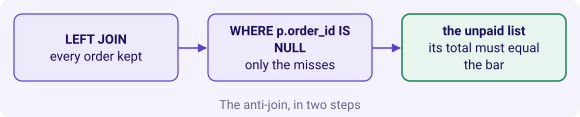

In [4]:
anti = run("""
SELECT o.order_id, o.channel, o.amount AS booked
FROM tiny_orders o
LEFT JOIN tiny_payments p ON p.order_id = o.order_id
WHERE p.order_id IS NULL
ORDER BY o.order_id""")
show(anti, "Invented: the orders nothing matched", money=["booked"])
kit.flow(["LEFT JOIN\nevery order kept", "WHERE p.order_id IS NULL\nonly the misses", "the unpaid list\nits total must equal the bar"],
         kinds=["plain", "plain", "good"], title="The anti-join, in two steps")
kit.check("the invented unpaid list's total equals the bridge's never-paid bar",
          sum(r["booked"] for r in anti) == tb["never_paid"], f'{int(tb["never_paid"]):,}')

**What happened.** The answer is a, T-4 alone, booked at 800, which is exactly the bridge's
never-paid bar. T-9 is not an order, so it cannot be on a list of orders; it belongs to the
platform lead's list at level 5.

**Your turn.** Run the same anti-join on Kalpa's Q2. In the empty cell below, type:

```python
unpaid = run(Q_UNPAID)
show(unpaid, "Q2 orders with no payment at all", money=["booked"])
print(len(unpaid), "orders,", kit.rupees(sum(r["booked"] for r in unpaid)))
```

`Q_UNPAID` is defined in the cell after it, which checks, without printing anything, that your
list's total equals the never-paid bar you computed in chapter 3.

In [5]:
Q_UNPAID = """
SELECT o.order_id, o.channel, o.order_date, o.amount AS booked
FROM orders o
LEFT JOIN payments p ON p.order_id = o.order_id
WHERE o.quarter = 'Q2'
  AND p.order_id IS NULL
ORDER BY o.amount DESC"""
unpaid_rows = run(Q_UNPAID)
kit.check("Kalpa's unpaid list totals the never-paid bar of the bridge",
          sum(r["booked"] for r in unpaid_rows) == kb["never_paid"], "equal to the rupee")
paid_on_list = one("SELECT count(*) FROM payments WHERE order_id = ANY(%s)", ([r["order_id"] for r in unpaid_rows],))
kit.check("no order on Kalpa's unpaid list has a payment row", paid_on_list == 0, "checked against payments")

## 2. What happens to the unpaid list when "paid in Q2" goes into the WHERE clause?

**The plausible wrong answer.** Anand talks about the cash that came in during Q2, so a teammate adds
the quarter's dates to the unpaid list, in the WHERE clause, beside the anti-join's condition:

```sql
SELECT o.order_id, o.amount AS booked
FROM tiny_orders o
LEFT JOIN tiny_payments p ON p.order_id = o.order_id
WHERE p.paid_date BETWEEN '2026-07-01' AND '2026-09-30'
  AND p.order_id IS NULL;
```

**Predict before you run.** How many orders does it list? a) 1, T-4; b) 0; c) 5; d) 2, T-2 and T-3.

order_id,payment_id,paid_date
T-1,P-1,2026-07-03
T-2,P-2,2026-07-05
T-2,P-3,2026-08-05
T-3,P-4,2026-07-09
T-3,P-5,2026-07-09
T-5,P-6,2026-07-12


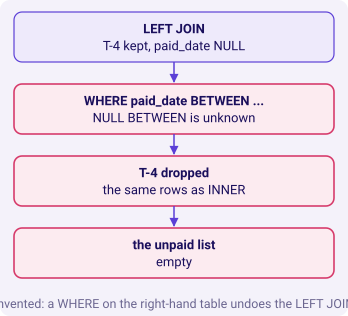

In [6]:
where_join = run("""
SELECT o.order_id, p.payment_id, p.paid_date
FROM tiny_orders o
LEFT JOIN tiny_payments p ON p.order_id = o.order_id
WHERE p.paid_date BETWEEN '2026-07-01' AND '2026-09-30'
ORDER BY o.order_id, p.payment_id""")
where_list = run("""
SELECT o.order_id, o.amount AS booked
FROM tiny_orders o
LEFT JOIN tiny_payments p ON p.order_id = o.order_id
WHERE p.paid_date BETWEEN '2026-07-01' AND '2026-09-30'
  AND p.order_id IS NULL""")
show(where_join, "Invented: the LEFT JOIN with the quarter in WHERE")
kit.stats([(f"{len(where_join)}", "rows after the WHERE", "the INNER JOIN's count"),
           (f"{len(where_list)}", "orders on the unpaid list", "the bar says 800 is unpaid"),
           ("T-4", "missing", "its paid_date is NULL")])
kit.vflow(["LEFT JOIN\nT-4 kept, paid_date NULL", "WHERE paid_date BETWEEN ...\nNULL BETWEEN is unknown",
           "T-4 dropped\nthe same rows as INNER", "the unpaid list\nempty"],
          kinds=["plain", "bad", "bad", "bad"], title="Invented: a WHERE on the right-hand table undoes the LEFT JOIN")

**What happened.** The answer is b: no orders. The join itself returns 6 rows, the same count as the
INNER JOIN in chapter 1, and T-4 is gone from them.

**Why it is wrong.** After the LEFT JOIN, T-4's row carries NULL in every payments column, including
`paid_date`. `NULL BETWEEN` two dates evaluates to unknown, and WHERE keeps only rows that are true,
so T-4 is thrown away after the join has kept it. A condition on the right-hand
table in the WHERE clause turns the LEFT JOIN into an INNER one without a word, and the anti-join
condition that follows can never be met. The list supports the sentence "every Q2 order was paid
within the quarter", which is false, and the collections team gets an empty list.

**The check that catches it.** The list's total must equal its bar: 0 against the bridge's 800 never
paid. Counting the join's rows against the orders, 6 rows where the LEFT JOIN returns 7, points at
the same fault.

## 3. Where does a condition on the payments table belong?

It belongs in the ON clause. ON decides which payment rows count as a match, before the join; WHERE decides
which joined rows survive, after it. The PostgreSQL manual says that a restriction placed in the ON
clause "is processed before the join, while a restriction placed in the WHERE clause is processed
after the join", and that the difference "matters a lot with outer joins" (PostgreSQL 16
documentation, section 7.2.1.1, Joined Tables, checked 1 Oct 2026).

**Predict before you run.** With the dates moved into ON, how many rows does the join return, and
which orders does the unpaid list hold? a) 6 rows, no orders; b) 7 rows, T-4; c) 7 rows, T-4 and T-9;
d) 8 rows, T-4.

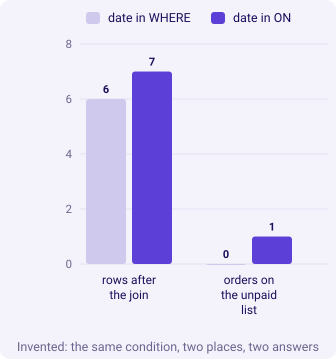

order_id,booked
T-4,Rs 800


In [7]:
on_join = run("""
SELECT o.order_id, p.payment_id, p.paid_date
FROM tiny_orders o
LEFT JOIN tiny_payments p
       ON p.order_id = o.order_id
      AND p.paid_date BETWEEN '2026-07-01' AND '2026-09-30'
ORDER BY o.order_id, p.payment_id""")
on_list = run("""
SELECT o.order_id, o.amount AS booked
FROM tiny_orders o
LEFT JOIN tiny_payments p
       ON p.order_id = o.order_id
      AND p.paid_date BETWEEN '2026-07-01' AND '2026-09-30'
WHERE p.order_id IS NULL""")
kit.columns(["rows after the join", "orders on the unpaid list"],
            [("date in WHERE", [len(where_join), len(where_list)]), ("date in ON", [len(on_join), len(on_list)])],
            title="Invented: the same condition, two places, two answers")
show(on_list, "Invented: the unpaid list with the date condition in ON", money=["booked"])
kit.check("with the condition in ON, the join keeps every order", len({r["order_id"] for r in on_join}) == 5,
          f"{len(on_join)} rows")
kit.check("with the condition in ON, the list holds T-4 and matches the bar",
          [r["order_id"] for r in on_list] == ["T-4"] and sum(r["booked"] for r in on_list) == tb["never_paid"], "T-4, 800")

**What happened.** The answer is b: 7 rows and T-4 on the list, booked at 800, the bar exactly.
Moving one condition from WHERE to ON changed the whole list. The rule to keep is that in a LEFT
JOIN a condition on the right-hand table goes in ON, and the one WHERE condition that belongs on the
right table is the anti-join's `IS NULL`, unless the question wants matched rows only.

The two lists answer different questions. With the dates in ON, the list holds the orders not paid
within Q2, so an order paid on 3 October would be on it; for "never paid", no date condition belongs
on payments at all. On the invented tables and on Kalpa's Q2 the two lists hold the same orders, only
because no payment in the warehouse lands after 30 September.

## 4. Which orders does HAVING COUNT(*) > 1 flag, and are they double-paid?

**The plausible wrong answer.** For the double-paid list, a teammate reaches for what Monday taught:
group Q2's payments by order and keep the orders with more than one row.

```sql
SELECT o.order_id, count(*) AS payment_rows
FROM orders o
JOIN payments p ON p.order_id = o.order_id
WHERE o.quarter = 'Q2'
GROUP BY o.order_id
HAVING count(*) > 1;
```

**Predict before you run.** Anand will ask the payments team to reverse the second payment on every
order this returns. How long is the list? a) a handful of orders, each paid twice; b) 216 orders,
including every one of Q2's ten largest invoices; c) no rows, since payment ids are unique; d) all
462 Q2 orders.

order_id,payment_rows,beyond_one_payment
T-2,2,Rs 800
T-3,2,"Rs 1,500"


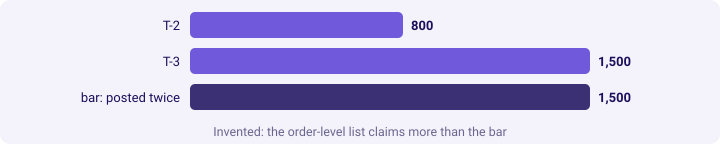

In [8]:
flagged = run("""
SELECT o.order_id, count(*) AS payment_rows
FROM orders o
JOIN payments p ON p.order_id = o.order_id
WHERE o.quarter = 'Q2'
GROUP BY o.order_id
HAVING count(*) > 1""")
top_ten = [r["order_id"] for r in run("""
SELECT o.order_id, o.channel, o.status, o.amount AS booked,
       count(p.payment_id) AS payment_rows,
       string_agg(p.instalment_no::text, ' and ' ORDER BY p.instalment_no) AS instalments
FROM orders o
LEFT JOIN payments p ON p.order_id = o.order_id
WHERE o.quarter = 'Q2'
GROUP BY o.order_id, o.channel, o.status, o.amount
ORDER BY o.amount DESC
LIMIT 10""")]
flagged_ids = {r["order_id"] for r in flagged}
tiny_flagged = run("""
SELECT p.order_id, count(*) AS payment_rows, sum(p.amount) - max(p.amount) AS beyond_one_payment
FROM tiny_payments p
JOIN tiny_orders o ON o.order_id = p.order_id
GROUP BY p.order_id
HAVING count(*) > 1
ORDER BY p.order_id""")
show(tiny_flagged, "Invented: the same query on the tiny tables, with what lies beyond one payment",
     money=["beyond_one_payment"])
kit.stats([(f"{len(flagged)}", "Q2 orders flagged", "more than one payment row each"),
           (f"{sum(1 for t in top_ten if t in flagged_ids)} of 10", "largest Q2 orders on it", "all paid in instalments 1 and 2"),
           (f'{int(sum(r["beyond_one_payment"] for r in tiny_flagged)):,}', "invented surplus it claims", "the bar says 1,500")])
kit.bars([(r["order_id"], float(r["beyond_one_payment"])) for r in tiny_flagged] + [("bar: posted twice", float(tb["posted_twice"]))],
         lit=[2], fmt=lambda v: f"{v:,.0f}", title="Invented: the order-level list claims more than the bar")

**What happened.** The answer is b: 216 Q2 orders, and every one of the ten largest Q2 invoices is on
it, each paid in instalments 1 and 2. On the invented tables the same query flags T-2 and T-3 and
claims 2,300 posted beyond one payment, against a bar of 1,500.

**Why it is wrong.** Two payment rows can be two instalments or one payment posted twice, and a count
of rows cannot tell them apart. T-2's second row is its second instalment, real cash; T-3's second
row is the retry. A note asking the payments team to reverse the second payment on all 216 orders
would reverse legitimate second instalments on Kalpa's largest business invoices and put a call to
every corporate buyer who paid on time.

**The check that catches it.** The list's surplus must equal the bridge's posted-twice bar, and on
the invented tables it claims 2,300 against 1,500.

In [9]:
kit.check("the order-level list flags every one of Q2's ten largest orders",
          all(t in flagged_ids for t in top_ten), f"{len(flagged)} orders flagged")
kit.check("on the invented tables, the order-level list's surplus disagrees with the bar",
          sum(r["beyond_one_payment"] for r in tiny_flagged) != tb["posted_twice"],
          f'{int(sum(r["beyond_one_payment"] for r in tiny_flagged)):,} against {int(tb["posted_twice"]):,}')

## 5. What makes a retry a retry, and does each list match its bar?

A gateway retry posts the same instalment of the same order twice; a second instalment has its own
instalment number. So the double-paid grain is the order and the instalment, and the amount posted
twice is what lies beyond one payment of that instalment.

**Predict before you run.** Grouped by `order_id` and `instalment_no`, which invented orders stay on
the list, and what is posted twice? a) T-2 and T-3, 2,300; b) T-3, 1,500; c) T-2, 800; d) none.

order_id,instalment_no,times_posted,posted_twice
T-3,1,2,"Rs 1,500"


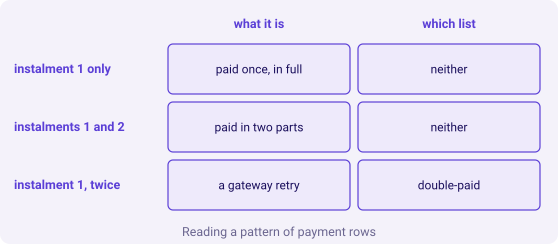

In [10]:
retries = run("""
SELECT p.order_id, p.instalment_no, count(*) AS times_posted,
       sum(p.amount) - max(p.amount) AS posted_twice
FROM tiny_payments p
JOIN tiny_orders o ON o.order_id = p.order_id
GROUP BY p.order_id, p.instalment_no
HAVING count(*) > 1
ORDER BY p.order_id""")
show(retries, "Invented: one order and instalment posted more than once", money=["posted_twice"])
kit.matrix(["instalment 1 only", "instalments 1 and 2", "instalment 1, twice"],
           ["what it is", "which list"],
           [["paid once, in full", "neither"], ["paid in two parts", "neither"], ["a gateway retry", "double-paid"]],
           title="Reading a pattern of payment rows")
kit.check("the invented double-paid list is T-3's instalment 1", [(r["order_id"], r["instalment_no"]) for r in retries] == [("T-3", 1)],
          "T-3, instalment 1")
kit.check("its surplus equals the bridge's posted-twice bar", sum(r["posted_twice"] for r in retries) == tb["posted_twice"],
          f'{int(tb["posted_twice"]):,}')

**What happened.** The answer is b: T-3's instalment 1, posted twice, 1,500 posted beyond one payment,
which is the bar exactly. T-2 left the list, because its two rows carry two instalment numbers.

**Your turn.** Build both of Kalpa's remaining lists. In the empty cell below, type:

```python
double_paid = run(Q_RETRIES)
show(double_paid, "Q2 instalments posted more than once", money=["posted_twice"])
orphans = run(Q_ORPHANS)
show(orphans, "Payments whose order is not in the orders table", money=["amount"])
```

The double-paid list goes to the platform lead and Finance. The last query is a third finding:
payments that match no order at all, which goes back to the platform lead with its payment ids.
The cell after it defines both queries and checks, without printing, that the double-paid list
matches its bar and that every one of the 1,428 payment rows is accounted for.

In [11]:
Q_RETRIES = """
SELECT p.order_id, o.channel, p.instalment_no, count(*) AS times_posted,
       sum(p.amount) - max(p.amount) AS posted_twice
FROM payments p
JOIN orders o ON o.order_id = p.order_id
WHERE o.quarter = 'Q2'
GROUP BY p.order_id, o.channel, p.instalment_no
HAVING count(*) > 1
ORDER BY p.order_id"""
Q_ORPHANS = """
SELECT p.payment_id, p.order_id AS paid_for, p.paid_date, p.method, p.amount
FROM payments p
LEFT JOIN orders o ON o.order_id = p.order_id
WHERE o.order_id IS NULL
ORDER BY p.payment_id"""
retry_rows = run(Q_RETRIES)
orphan_rows = run(Q_ORPHANS)
homes = {r["home"]: r["payment_rows"] for r in run("""
SELECT coalesce(o.quarter, 'no order') AS home, count(*) AS payment_rows
FROM payments p
LEFT JOIN orders o ON o.order_id = p.order_id
GROUP BY coalesce(o.quarter, 'no order')""")}
total_rows = one("SELECT count(*) FROM payments")
kit.check("Kalpa's double-paid list totals the bridge's posted-twice bar",
          sum(r["posted_twice"] for r in retry_rows) == kb["posted_twice"], "equal to the rupee")
kit.check("every payment row is on a Q1 order, a Q2 order or no order, and they add to the table",
          sum(homes.values()) == total_rows, f"{total_rows:,} rows accounted for")
kit.check("the orphan query finds exactly the rows on no order", len(orphan_rows) == homes.get("no order", 0),
          "count unprinted")

Kavya Nair, the team's senior analyst, reviews every number before it leaves the team.

> **Kavya's review.** "Two payment rows are not a double payment. Show me what makes a retry a retry
> before anyone rings a customer, and show me that each list adds up to its bar."

## Do a second method and a second list reach the same orders?

The unpaid list is checked a way that builds no anti-join at all: count the orders, take away the
orders that appear in payments, and do the same with their booked amounts. What is left must equal
the list's count and total; a WHERE that empties the anti-join, or a NULL that silences it, cannot
reach this route. The double-paid list is found a second way that never reads an instalment number:
an order whose posted cash exceeds what it was booked for has been paid more than once. The
instalment method would miss a retry the feed wrote under a new instalment number, and the booked
method would miss a retry on an order paid short. When both find the same orders, the only retry
that could still hide is one with both blind spots at once, a new instalment number on an order
that is also paid short.

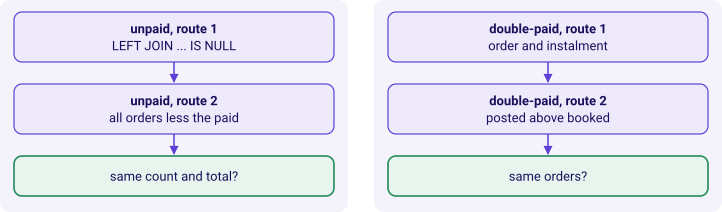

In [12]:
sub_tiny = run("""
SELECT (SELECT count(*) FROM tiny_orders)
         - (SELECT count(DISTINCT order_id) FROM tiny_payments
             WHERE order_id IN (SELECT order_id FROM tiny_orders)) AS unpaid_orders,
       (SELECT sum(amount) FROM tiny_orders)
         - (SELECT sum(amount) FROM tiny_orders
             WHERE order_id IN (SELECT order_id FROM tiny_payments)) AS unpaid_booked""")[0]
cap_tiny = run("""
WITH posted_per_order AS (SELECT order_id, sum(amount) AS posted FROM tiny_payments GROUP BY order_id)
SELECT o.order_id FROM tiny_orders o JOIN posted_per_order pp ON pp.order_id = o.order_id
WHERE pp.posted > o.amount""")
kit.side_by_side(
    kit.vflow(["unpaid, route 1\nLEFT JOIN ... IS NULL", "unpaid, route 2\nall orders less the paid", "same count and total?"],
              kinds=["plain", "plain", "good"], show=False),
    kit.vflow(["double-paid, route 1\norder and instalment", "double-paid, route 2\nposted above booked", "same orders?"],
              kinds=["plain", "plain", "good"], show=False),
)
kit.check("invented: all orders less the paid ones leave the unpaid list's count and total",
          (sub_tiny["unpaid_orders"], sub_tiny["unpaid_booked"]) == (len(anti), sum(r["booked"] for r in anti)),
          "1 order, 800, both ways")
kit.check("invented: posted above booked flags the same order as the instalment method",
          [r["order_id"] for r in cap_tiny] == [r["order_id"] for r in retries], "T-3 both ways")
sub_kalpa = run("""
SELECT (SELECT count(*) FROM orders WHERE quarter = 'Q2')
         - (SELECT count(DISTINCT order_id) FROM payments
             WHERE order_id IN (SELECT order_id FROM orders WHERE quarter = 'Q2')) AS unpaid_orders,
       (SELECT sum(amount) FROM orders WHERE quarter = 'Q2')
         - (SELECT sum(amount) FROM orders
             WHERE quarter = 'Q2' AND order_id IN (SELECT order_id FROM payments)) AS unpaid_booked""")[0]
cap_kalpa = {r["order_id"] for r in run("""
WITH posted_per_order AS (
    SELECT order_id, sum(amount) AS posted FROM payments GROUP BY order_id
)
SELECT o.order_id
FROM orders o
JOIN posted_per_order pp ON pp.order_id = o.order_id
WHERE o.quarter = 'Q2' AND pp.posted > o.amount""")}
kit.check("Kalpa: all Q2 orders less the paid ones leave the unpaid list's count and total",
          (sub_kalpa["unpaid_orders"], sub_kalpa["unpaid_booked"]) == (len(unpaid_rows), sum(r["booked"] for r in unpaid_rows)),
          "equal, unprinted")
kit.check("Kalpa: posted above booked flags the same orders as the instalment method",
          cap_kalpa == {r["order_id"] for r in retry_rows}, "same ids, unprinted")

**What happened.** Both second routes agree with the first, on the invented tables and on Kalpa's Q2:
the same count and total of unpaid orders by subtraction, and the same double-paid orders whether
the retry is found by its instalment number or by its cash exceeding its booking.

### In the interview: how do you find the unpaid orders and the double-paid ones?

The tags mark how often a question comes up: [S] a staple asked everywhere, [F] frequent in GCC and product screens, [D] a differentiator.

**[F] How do you find orders with no payment?** Use an anti-join: a LEFT JOIN from orders to payments that keeps the rows where the payment side is
NULL, or NOT EXISTS, which says the same thing in the order of the sentence. Then check the list
against figures computed without it: its booked total must equal total booked less total collected,
less anything paid in part, or the list is wrong. Avoid NOT IN, which returns nothing once the
subquery holds a single NULL.

**[F] A filter on the right-hand table of a LEFT JOIN: WHERE or ON, and what changes?** It goes in ON. In ON the filter decides which right-hand rows count as a match, and every left row survives; in
WHERE it runs after the join, the unmatched rows carry NULL, NULL fails the filter, and the LEFT
JOIN behaves as an INNER one. The only right-table condition that belongs in WHERE is the anti-join's
`IS NULL`, unless the question wants matched rows only, where the INNER result is the honest one.

**[F] HAVING COUNT(*) > 1 on payments by order: what does it find, and what does it wrongly include?** It finds every order with more than one payment row, which includes orders legitimately paid in
instalments. The retry grain is the order and the instalment, and the proof is that the list's
surplus equals posted less collected.

### Depth: why does NOT IN return nothing when the subquery holds a NULL?

`x NOT IN (a, b, NULL)` means `x <> a AND x <> b AND x <> NULL`. The last comparison is unknown for
every x, so the whole condition is never true, and WHERE keeps no row. It is the same three-valued
logic that made the WHERE clause drop T-4 at level 2.

## What did this chapter answer, one line per question?

1. The orders with no payment are found by an anti-join; on the invented tables it is T-4 at 800,
   the never-paid bar exactly, and on Kalpa's Q2 your list matches its bar too.
2. With "paid in Q2" in the WHERE clause the join shrinks to the INNER JOIN's 6 rows and the unpaid
   list comes back empty, because NULL fails the date test.
3. A condition on the payments table belongs in ON, which restores 7 rows and T-4.
4. HAVING COUNT(*) > 1 by order flags 216 Q2 orders, every one of the ten largest invoices among
   them, because two instalments are two rows too.
5. A retry is the same order and instalment posted twice; grouped that way the invented list is
   T-3's 1,500, the bar exactly, and Kalpa's list matches its bar.
6. All orders less the paid ones leave the unpaid list's count and total, and posted above booked
   flags the same double-paid orders, on both sets of tables.

**The question this leaves.** Anand has the bridge and its two lists, so chapter 5 asks what goes on
the one page he signs, by channel, and whether its gap column tells the truth.

In [13]:
kit.check_summary()